In [ ]:
# input
pred_prob_file = "../../../predict_afdb/data/pred_ge_3_clique_3.tsv"
aligned_result = "../data/pred_cluster_aligned_result.tsv"
# output
fig_file = "./fig/consistency_ratio_to_proba_median.pdf"

In [ ]:
import pandas as pd

df = pd.read_table(pred_prob_file)
df['seq_id'] = df['seq_id'].map(lambda x: x.split("-")[1])
df['posi2pred_proba'] = df.apply(lambda row: dict(zip(row['posi'].split(","), row['pred'].split(","))), axis=1)
id2pred_proba = dict(zip(df['seq_id'], df['posi2pred_proba']))

def get_proba_str(row):

    seq_id = row['seq_id']
    posis = row['real_posi'].split(",")

    if seq_id not in id2pred_proba:
        return ""
    else:
        posi2proba = id2pred_proba[seq_id]
        posi_probas = ["0" if p not in posi2proba else posi2proba[p] for p in posis]
        return ",".join(posi_probas)

df = pd.read_table(aligned_result)
df['pred_proba'] = df.apply(lambda row: get_proba_str(row), axis=1)
df.head()

,seq_id,real_posi,real_aa,algined_posi,is_pred,rep_id,pred_proba
0,A0A009DXY7,"7,48,50","H,H,H","7,48,50","1,1,1",A0A009DXY7,"0.6576,0.6132,0.5556"
1,A0A009ECR5,"42,185,208","D,H,D","42,185,208","1,1,1",A0A009ECR5,"0.9626,0.7962,0.8761"
2,N9GAE8,"101,109,111","H,H,H","101,109,111","1,1,1",A0A009EFY2,"0.5094,0.4934,0.4606"
3,K2FLQ5,"101,109,111","H,H,H","101,109,111","1,1,1",A0A009EFY2,"0.5093,0.4934,0.4606"
4,N9QGU1,"101,109,111","H,H,H","101,109,111","1,1,1",A0A009EFY2,"0.5099,0.494,0.4603"


In [ ]:
import tqdm
import numpy as np

data = []
cluster_size_threshold = 10
for (rep_id,), df_rep in tqdm.tqdm(df.groupby(['rep_id'])):
    if len(df_rep) < cluster_size_threshold:
        continue
    
    df_pred = df_rep[df_rep['is_pred'].map(lambda x: x.count("1") > 0)]
    probas = [float(i) for r in list(df_pred['pred_proba']) for i in r.split(",")]
    probas = np.array(probas)
    probas = probas[probas != 0]

    pred_ratio = len(df_pred) / len(df_rep)
    proba_median = np.median(probas)
    data.append({
        "ratio": pred_ratio,
        "proba": proba_median
    })

100%|██████████| 7415834/7415834 [05:16<00:00, 23464.56it/s]


In [4]:
df_data = pd.DataFrame(data)
x = list(df_data['ratio'])
y = list(df_data['proba'])

{'whiskers': [<matplotlib.lines.Line2D at 0x7fb7b0de3b90>,
 'caps': [<matplotlib.lines.Line2D at 0x7fb850cc8b50>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fb7b0de3110>,
 'medians': [<matplotlib.lines.Line2D at 0x7fb850cc8d90>,
 'fliers': [],
 'means': []}

Text(0.5, 0, 'Consistency ratio')

Text(0, 0.5, 'Probability median')

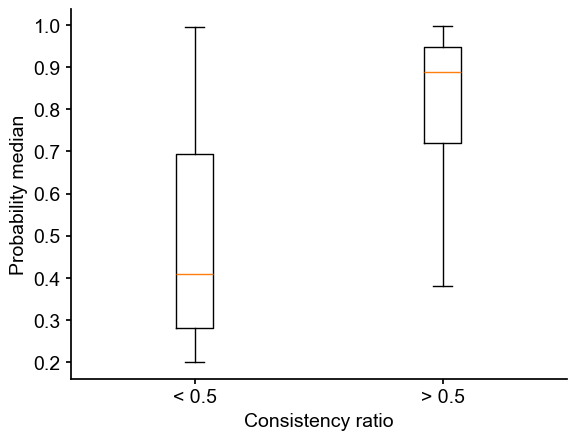

In [12]:
import matplotlib.pyplot as plt

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")

data1 = df_data[df_data['ratio'] < 0.5]['proba']
data2 = df_data[df_data['ratio'] > 0.5]['proba']
data = [data1, data2]

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.boxplot(data, tick_labels=['< 0.5', '> 0.5'], showfliers=False)
plt.xlabel("Consistency ratio")
plt.ylabel("Probability median")

plt.savefig(fig_file, bbox_inches="tight", transparent=True)